# Phase 4b - BM25 Sparse-Retrieval Baseline

Indexes the `text` column of `chunks_n200.parquet` (the shared Phase-3 control) and
scores retrieval against the frozen golden set from `04_golden_dataset.ipynb`.

**Execution order (do not reorder):** golden set → build index → retrieve → compute
metrics → generate figures. Figures are built *after* there are numbers to plot.

**Metric stance** (see `notes/phase_04_retrieval_decisions.md`): **MRR@K and Recall@K
are primary**; Precision@K is reported but interpreted with care (single-positive
queries cap it at 1/K). Primary breakdown = **EDGAR vs earnings**; subtype is exploratory.

In [15]:
# %load_ext autoreload
# %autoreload 2

%reload_ext autoreload

import sys, json, time, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.retrieval.bm25_retriever import (
    BM25Retriever, evaluate_retriever, metric_columns, load_chunks,
)
from src.retrieval.golden_dataset_builder import load_golden_set, hash_golden_set

CHUNKS_PATH = ROOT / "data" / "processed" / "chunks_n200.parquet"
GOLDEN_PATH = ROOT / "data" / "processed" / "golden_queries.parquet"
FIG_DIR     = ROOT / "reports" / "figures"
NOTES_DIR   = ROOT / "notes"
FIG_DIR.mkdir(parents=True, exist_ok=True)

K_VALUES = [1, 3, 5, 10]
SEED = 42

## 1. Load the frozen golden set (and verify its hash)

- Recomputes the SHA and prints it. (This is the pattern Phase 5/6 will reuse to assert equality.)

In [16]:
golden = load_golden_set(GOLDEN_PATH)
golden_hash = hash_golden_set(golden)
print(f"golden queries: {len(golden)} | SHA-256: {golden_hash}")
print("arm balance:", golden['source'].value_counts().to_dict())
# This hash MUST match the one Phases 5 & 6 use — proves identical evaluation set.
golden[['query_id','source','subtype','query_text']].head()

golden queries: 60 | SHA-256: 325634f065147a49d6fba6e0fb021107d536b1aa717bcbbb4a10b68b93c0e72e
arm balance: {'earnings': 30, 'edgar': 30}


,query_id,source,subtype,query_text
0,q000,earnings,qa,"In the closing remarks of the call, what did t..."
1,q001,earnings,qa,What productivity contribution percentage was ...
2,q002,earnings,full,How did management describe the effect of prom...
3,q003,earnings,prepared_remarks,What was the year-on-year growth rate of netwo...
4,q004,earnings,full,How did management describe its capital deploy...


## 2. Load chunks + build the BM25 index (timed)

- For n=100, Tokenises all ~21,050 chunks and builds the BM25Okapi index. Should take a couple of seconds on the i5. The timing goes into the summary.

In [17]:
chunks = load_chunks(CHUNKS_PATH)
print(f"{len(chunks):,} chunks loaded")

t0 = time.perf_counter()
retriever = BM25Retriever(chunks, text_col="text", id_col="chunk_id", k1=1.5, b=0.75)
build_s = time.perf_counter() - t0
print(f"BM25 index built over {len(retriever):,} chunks in {build_s:.2f}s "
      f"({len(retriever)/build_s:,.0f} chunks/s)")

21,050 chunks loaded
BM25 index built over 21,050 chunks in 2.55s (8,256 chunks/s)


## 3. Sanity check - a single retrieval is traceable end-to-end

- Every result carries `chunk_id` + metadata back to its filing / call / section.
- Sanity check : one traceable retrieval. Runs a single query and prints the top 3 results with their chunk_id, source/subtype, and company/filing. This is the eyeball confirmation that retrieval works and every hit traces back to its source. If this looks sane, the machinery is sound.

In [18]:
demo_q = golden.iloc[0]
print("query:", demo_q['query_text'])
print("relevant:", demo_q['relevant_chunk_ids'], "\n")
for r in retriever.retrieve(demo_q['query_text'], k=3):
    meta = json.loads(r['metadata']) if isinstance(r['metadata'], str) else r['metadata']
    tag = meta.get('company') or meta.get('filename') or meta.get('cik')
    print(f"  rank {r['rank']} | {r['chunk_id']} | {r['source']}/{r['subtype']} "
          f"| {tag} | score={r['score']:.2f}")

query: In the closing remarks of the call, what did the CEO thank participants for and say about the company's future?
relevant: ['earnings_0000_qa_chunk_030'] 

  rank 1 | earnings_0066_qa_chunk_014 | earnings/qa | Axon Enterprise | score=62.39
  rank 2 | earnings_0023_qa_chunk_032 | earnings/qa | Charles River Laboratories | score=61.41
  rank 3 | earnings_0005_prepared_chunk_000 | earnings/prepared_remarks | General Motors | score=60.60


## 4. Retrieve + compute metrics over the whole golden set (K = 1/3/5/10)

Recall@K = (relevant chunks found in top K) ÷ (total relevant chunks that exist for this query)

- Average that over 60 queries and Recall@5 becomes literally "what fraction of my 60 queries had their right chunk somewhere in the top 5?" 
That's why, in single-positive setups, Recall@K is also called Hit Rate or Success@K — it's the hit percentage. Clean and intuitive.

- Precision@K = (relevant found in top K) ÷ K. With one relevant chunk, 
the best it can do is 1 hit out of K, so Precision@5 maxes at 1/5 = 0.20, 
Precision@10 at 0.10. This is the capped metric 

- MRR@K = 1 ÷ (the rank position where the relevant chunk first appears), 
or 0 if it's not in the top K. 
Relevant chunk at rank 1 → 1.0; at rank 2 → 0.5; at rank 4 → 0.25. 
It rewards putting the right answer high, not just present. 
This is your sharpest signal: Recall says "did you find it," 
MRR says "how near the top did you put it."

    - Recall = did the right chunk make the top K at all; 
    - MRR = how high up; Precision = (capped, less informative here).
    - Recall and MRR are what will be actually interpreted.

In [19]:
t0 = time.perf_counter()
per_q = evaluate_retriever(retriever, golden, k_values=K_VALUES)
eval_s = time.perf_counter() - t0
COLS = metric_columns(K_VALUES)
print(f"scored {len(per_q)} queries in {eval_s:.2f}s")
per_q.head()

scored 60 queries in 8.41s


,query_id,source,subtype,n_relevant,precision@1,recall@1,mrr@1,precision@3,recall@3,mrr@3,precision@5,recall@5,mrr@5,precision@10,recall@10,mrr@10
0,q000,earnings,qa,1,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.1,1.0,0.125000
1,q001,earnings,qa,1,0.0,0.0,0.0,0.333333,1.0,0.333333,0.2,1.0,0.333333,0.1,1.0,0.333333
2,q002,earnings,full,1,1.0,1.0,1.0,0.333333,1.0,1.000000,0.2,1.0,1.000000,0.1,1.0,1.000000
3,q003,earnings,prepared_remarks,1,0.0,0.0,0.0,0.000000,0.0,0.000000,0.2,1.0,0.200000,0.1,1.0,0.200000
4,q004,earnings,full,1,1.0,1.0,1.0,0.333333,1.0,1.000000,0.2,1.0,1.000000,0.1,1.0,1.000000


### 4a. Overall metrics

In [20]:
overall = per_q[COLS].mean().to_frame("overall").T
overall.round(3)

,precision@1,recall@1,mrr@1,precision@3,recall@3,mrr@3,precision@5,recall@5,mrr@5,precision@10,recall@10,mrr@10
overall,0.567,0.567,0.567,0.239,0.717,0.631,0.157,0.783,0.645,0.088,0.883,0.658


### 4b. Primary breakdown - EDGAR vs earnings

pandas-3 safe: `groupby(...)[cols].mean()`, **not** `groupby.apply` (removed in pandas 3).

In [21]:
by_source = per_q.groupby("source")[COLS].mean()
by_source.round(3)

,precision@1,recall@1,mrr@1,precision@3,recall@3,mrr@3,precision@5,recall@5,mrr@5,precision@10,recall@10,mrr@10
source,,,,,,,,,,,,
earnings,0.700,0.700,0.700,0.256,0.767,0.728,0.167,0.833,0.741,0.093,0.933,0.754
edgar,0.433,0.433,0.433,0.222,0.667,0.533,0.147,0.733,0.548,0.083,0.833,0.562


### 4c. Exploratory breakdown - by subtype (small per-cell n; indicative only)

In [22]:
by_subtype = per_q.groupby("subtype")[COLS].mean()
by_subtype["n_queries"] = per_q.groupby("subtype").size()
by_subtype.round(3)

,precision@1,recall@1,mrr@1,precision@3,recall@3,mrr@3,precision@5,recall@5,mrr@5,precision@10,recall@10,mrr@10,n_queries
subtype,,,,,,,,,,,,,
full,0.818,0.818,0.818,0.303,0.909,0.864,0.200,1.000,0.882,0.100,1.000,0.882,11
prepared_remarks,0.571,0.571,0.571,0.190,0.571,0.571,0.143,0.714,0.600,0.071,0.714,0.600,7
qa,0.667,0.667,0.667,0.250,0.750,0.694,0.150,0.750,0.694,0.100,1.000,0.726,12
section_1,0.667,0.667,0.667,0.278,0.833,0.722,0.167,0.833,0.722,0.100,1.000,0.746,6
section_1A,0.100,0.100,0.100,0.200,0.600,0.317,0.140,0.700,0.342,0.080,0.800,0.352,10
section_7,0.500,0.500,0.500,0.222,0.667,0.583,0.133,0.667,0.583,0.083,0.833,0.611,6
section_8,0.625,0.625,0.625,0.208,0.625,0.625,0.150,0.750,0.650,0.075,0.750,0.650,8


## 5. Validation / sanity assertions

In [23]:
# Monotonicity: recall and MRR are non-decreasing in K (larger window can only help).
for m in ["recall", "mrr"]:
    vals = [overall.iloc[0][f"{m}@{k}"] for k in K_VALUES]
    assert all(b >= a - 1e-9 for a, b in zip(vals, vals[1:])), f"{m} not monotonic in K: {vals}"

# Metrics bounded [0,1]
assert per_q[COLS].to_numpy().min() >= 0.0 and per_q[COLS].to_numpy().max() <= 1.0

# Every golden query has >=1 relevant chunk
assert (golden['relevant_chunk_ids'].apply(len) >= 1).all()

print("all sanity assertions passed ✓")

all sanity assertions passed ✓


## 6. Figures

Generated **after** the numbers exist. Saved to `reports/figures/` with the
`phase04_` naming convention.

### Fig - metrics across K (overall)

- Recall@K = (relevant chunks found in top K) ÷ (total relevant chunks that exist for this query). In single-positive setups, Recall@K is also called Hit Rate or Success@K, it's the hit percentage. Clean and intuitive. Because the choosen one is single-positive, the denominator - "total relevant chunks that exist for this query" — is always 1. There's exactly one relevant chunk per query. So the Recall@K collapses to a simple yes/no:

    - The relevant chunk is in the top K → Recall@K = 1/1 = 1.0
    - The relevant chunk is not in the top K → Recall@K = 0/1 = 0.0

Therefore, averaging that over 60 queries and Recall@5 becomes literally "what fraction of the 60 queries (from golden set) had their right chunk somewhere in the top 5?"

- Precision@K = (relevant found in top K) ÷ K. With one relevant chunk, the best that can be done is 1 hit out of K, so Precision@5 maxes at 1/5 = 0.20, Precision@10 at 0.10. This is the capped metric so report it, but don't read a low number as failure.

- MRR@K = 1 ÷ (the rank position where the relevant chunk first appears), or 0 if it's not in the top K. Relevant chunk at rank 1 → 1.0; at rank 2 → 0.5; at rank 4 → 0.25. It rewards putting the right answer high, not just present. This is the sharpest signal here: Recall says "did you find it," MRR says "how near the top did you put it."

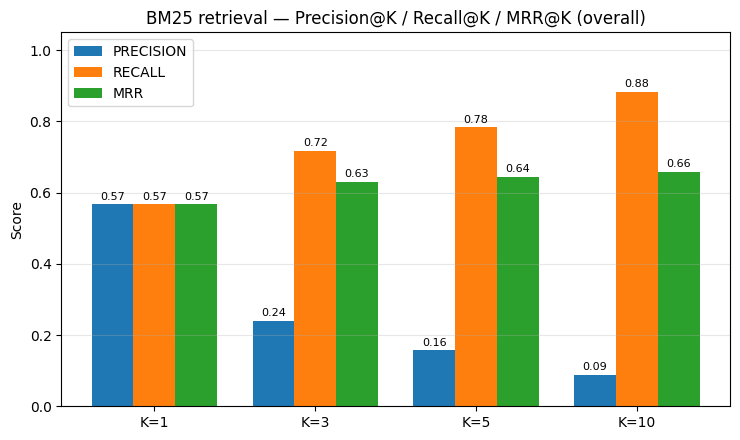

In [24]:
metrics = ["precision", "recall", "mrr"]
x = np.arange(len(K_VALUES)); w = 0.26
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for j, m in enumerate(metrics):
    vals = [overall.iloc[0][f"{m}@{k}"] for k in K_VALUES]
    bars = ax.bar(x + (j - 1) * w, vals, w, label=m.upper())
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels([f"K={k}" for k in K_VALUES])
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("BM25 retrieval — Precision@K / Recall@K / MRR@K (overall)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "phase04_metrics_by_k.png", dpi=150, bbox_inches="tight")
plt.show()

Figure 5. BM25 retrieval performance across cut-off K (overall).
Precision@K, Recall@K, and MRR@K for the BM25 baseline at K = 1, 3, 5, 10, averaged over all 60 golden queries. 
Recall rises monotonically from 0.57 at K=1 to 0.88 at K=10, 
while MRR plateaus near 0.66, indicating that when the relevant chunk is retrieved it typically ranks first or second. 
Precision declines from 0.57 to 0.09 purely as an artifact of the single-positive judgement design 
(where Precision@K is capped at 1/K), and should not be read as degrading performance. 
The chart establishes BM25 as a strong single-retriever baseline against which the dense and hybrid configurations are compared.

### Fig - EDGAR vs earnings (the formal-vs-conversational contrast)

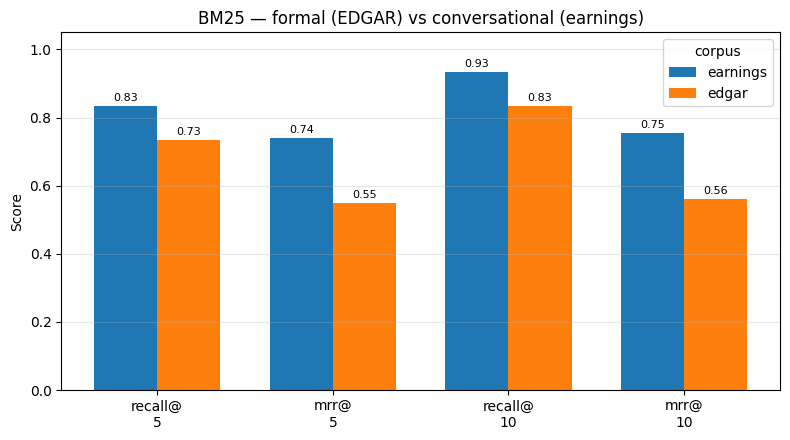

In [25]:
focus = ["recall@5", "mrr@5", "recall@10", "mrr@10"]  # primary metrics
arms = by_source.index.tolist()
x = np.arange(len(focus)); w = 0.36
fig, ax = plt.subplots(figsize=(8, 4.5))
for j, arm in enumerate(arms):
    vals = [by_source.loc[arm, m] for m in focus]
    bars = ax.bar(x + (j - 0.5) * w, vals, w, label=arm)
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels([m.replace("@", "@\n") for m in focus])
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("BM25 — formal (EDGAR) vs conversational (earnings)")
ax.legend(title="corpus"); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "phase04_edgar_vs_earnings.png", dpi=150, bbox_inches="tight")
plt.show()

Figure 6. BM25 performance on formal (EDGAR) versus conversational (earnings) narratives.
Recall@5/10 and MRR@5/10 for the BM25 baseline, split by corpus. Earnings (conversational) 
outperforms EDGAR (formal) on every metric, most sharply on MRR@5 (0.74 vs 0.55), 
showing that lexical retrieval not only locates the relevant chunk more often in conversational 
calls but ranks it substantially higher. The gap is attributed to the structural redundancy of 
formal filings, EDGAR units yield roughly twice the chunks per document of earnings units (Phase 3), 
so boilerplate-heavy 10-K text produces many near-identical sibling chunks that dilute the lexical signal. 
This is the central retrieval-stage contrast of the study and motivates the hypothesis that dense embeddings will narrow the EDGAR-earnings gap.

### Fig - per-subtype MRR@10 (exploratory)

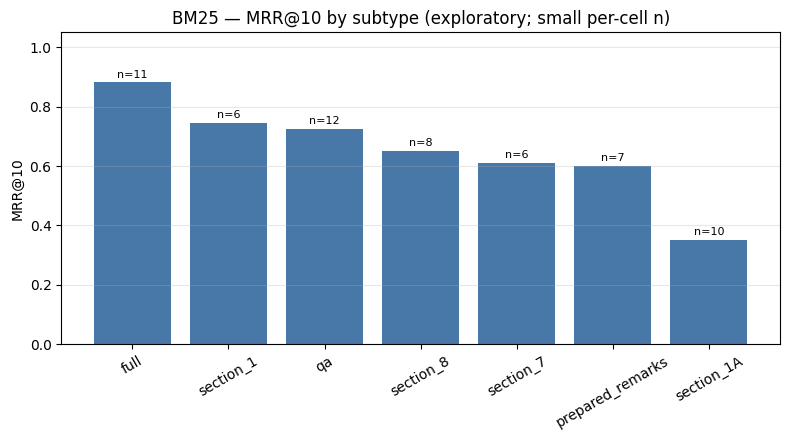

In [26]:
sub = by_subtype.sort_values("mrr@10", ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(sub.index, sub["mrr@10"], color="#4878a8")
ax.bar_label(bars, labels=[f"n={int(n)}" for n in sub["n_queries"]], fontsize=8, padding=2)
ax.set_ylabel("MRR@10"); ax.set_ylim(0, 1.05)
ax.set_title("BM25 — MRR@10 by subtype (exploratory; small per-cell n)")
ax.tick_params(axis="x", rotation=30); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "phase04_mrr_by_subtype.png", dpi=150, bbox_inches="tight")
plt.show()

Figure 7. BM25 mean MRR@10 by document subtype (exploratory).
Per-subtype mean MRR@10 with the number of golden queries annotated on each bar (n = 6–12 per subtype). 
Conversational full earnings calls rank highest (0.88) and section_1A Risk Factors lowest (0.35), 
consistent with the formal-redundancy interpretation, since risk-factor disclosures are the most boilerplate-similar text in a 10-K. 
Owing to the small per-cell sample sizes these differences are indicative rather than inferential, 
reported to surface gross register-level patterns and to be revisited at the n=500 scale-up.

<hr>

#### What n means
- n is simply how many of your 60 golden queries fall into that subtype. Nothing more. When you built the golden set, each query was generated from a seed chunk, and that chunk belonged to a subtype (full, qa, section_1A, etc.). So:

    - full, n=11 → 11 of your 60 queries target earnings "full" chunks
    - qa, n=12 → 12 queries target Q&A chunks
    - section_1, n=6 → 6 queries target Business-section chunks
    - section_1A, n=10 → 10 queries target Risk-Factors chunks

- Add them up: 11 + 6 + 12 + 8 + 6 + 7 + 10 = 60. ✓ That's your whole golden set, sliced by which subtype each query belongs to. The counts are uneven because the stratified sampler allocated queries proportionally to how many chunks each subtype has in the corpus (and some subtypes are just bigger than others), not because anything went wrong.

- What the bar height (MRR@10) means
The bar is the average MRR@10 across just those n queries. So for section_1 (n=6), the bar at 0.75 means: take those 6 queries, compute each one's MRR@10 (1/rank of its relevant chunk, or 0 if not in top 10), average the 6 numbers → 0.75.
So the two numbers answer different questions:

    - n = how many queries this average is built from (the sample size of the bar)
    - bar height = how well BM25 did on those queries (how high it ranked their relevant chunks)

- Why n matters for reading the chart — this is the real point
The whole reason I annotated n on each bar is that a bar built from 6 queries is far shakier than one built from 12. With n=6, a single query swinging from a hit to a miss moves the average by ~0.17. With n=12 it moves by ~0.08. So the small-n bars wobble more, and you shouldn't read fine differences between them as real.
Concretely: section_1 (0.75, n=6) sitting above qa (0.73, n=12) is not a meaningful difference — it's well within the noise that 6 queries produces. You can't conclude "BM25 is better at section_1 than qa" from that gap. What you can say is the gross pattern: the bottom bar, section_1A at 0.35, is low enough and far enough from the pack that it's probably a real signal even at n=10 — which is exactly the redundancy story (Risk Factors are the most boilerplate-similar text in a 10-K, so lexical retrieval struggles most to single out the right chunk).
That's why the figure title and your caption both say "exploratory; small per-cell n." It's an honest hedge: the chart is a hypothesis-generator (it points you at section_1A as the laggard to watch in Phase 5), not a place to draw firm subtype-by-subtype conclusions. Your primary breakdown — EDGAR vs earnings, 30 queries each — has enough per-cell n to support real claims; the subtype view does not, and the n labels are there so any reader can see that at a glance.

#### The subtype view (Figure, image 3) - one signal worth noting despite small n
Keep treating this as exploratory (4–12 per cell), but one pattern is strong enough to flag: section_1A (Risk Factors) is the clear laggard at MRR@10 = 0.35, far below everything else. That fits the redundancy story exactly — risk-factor sections are the most boilerplate-heavy, most self-similar text in a 10-K (every company's "our business may be adversely affected by…" reads alike), so lexical retrieval struggles most there. full earnings calls top the chart (0.88). I'd mention 1A specifically as the hardest register for sparse retrieval and a place to watch whether dense rescues it. Don't over-claim on the others given n.

## 7. Persist machine-readable summary

In [27]:
summary = {
    "phase": 4,
    "retriever": "bm25_okapi",
    "params": {"k1": 1.5, "b": 0.75, "tokenizer": "decimal_or_alpha_lowercase"},
    "chunks_indexed": int(len(retriever)),
    "index_build_seconds": round(build_s, 3),
    "golden_set": {
        "path": str(GOLDEN_PATH.relative_to(ROOT)),
        "sha256": golden_hash,
        "n_queries": int(len(golden)),
        "arm_balance": golden['source'].value_counts().to_dict(),
        "n_multi_positive": int((golden['relevant_chunk_ids'].apply(len) > 1).sum()),
        "generation_method": "llm_seed_curated",
        "seed": SEED,
    },
    "k_values": K_VALUES,
    "metrics_overall": {m: round(float(overall.iloc[0][m]), 4) for m in COLS},
    "metrics_by_source": {
        arm: {m: round(float(by_source.loc[arm, m]), 4) for m in COLS}
        for arm in by_source.index
    },
    "figures": [
        "reports/figures/phase04_metrics_by_k.png",
        "reports/figures/phase04_edgar_vs_earnings.png",
        "reports/figures/phase04_mrr_by_subtype.png",
    ],
}
with open(NOTES_DIR / "phase_04_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("wrote notes/phase_04_summary.json")
print(json.dumps(summary["metrics_by_source"], indent=2))

wrote notes/phase_04_summary.json
{
  "earnings": {
    "precision@1": 0.7,
    "recall@1": 0.7,
    "mrr@1": 0.7,
    "precision@3": 0.2556,
    "recall@3": 0.7667,
    "mrr@3": 0.7278,
    "precision@5": 0.1667,
    "recall@5": 0.8333,
    "mrr@5": 0.7411,
    "precision@10": 0.0933,
    "recall@10": 0.9333,
    "mrr@10": 0.7537
  },
  "edgar": {
    "precision@1": 0.4333,
    "recall@1": 0.4333,
    "mrr@1": 0.4333,
    "precision@3": 0.2222,
    "recall@3": 0.6667,
    "mrr@3": 0.5333,
    "precision@5": 0.1467,
    "recall@5": 0.7333,
    "mrr@5": 0.5483,
    "precision@10": 0.0833,
    "recall@10": 0.8333,
    "mrr@10": 0.562
  }
}
